In [1]:
using LinearAlgebra, QuantumOptics, DifferentialEquations, Plots, SparseArrays, JLD2, FileIO

## 4 atoms

In [12]:
const a = ComplexF64[1,0,0];        #Qubit state |0>
const b = ComplexF64[0,1,0];        #Qubit state |1>
const r = ComplexF64[0,0,1];       #Qubit state |r>

α = sqrt(0.5)
β = sqrt(1 - α^2)
ψ_1 = α .* b + β .* a; #Qubit state |ψ_1>
# ψ_1 = b
ψ_2 = a
ψ_3 = a
ψ_4 = a


ψ_a_op = Ket(NLevelBasis(3),ψ_1) ⊗ Ket(NLevelBasis(3),ψ_2) ⊗ Ket(NLevelBasis(3), ψ_3) ⊗ Ket(NLevelBasis(3), ψ_4)
ρ0_op = ψ_a_op ⊗ dagger(ψ_a_op);

In [13]:
function Precomputed_ops()
    basis = NLevelBasis(3)
    σx_1r = transition(basis, 2, 3) + transition(basis, 3, 2) #|1> <-> |r>
    σx_0r = transition(basis, 1, 3) + transition(basis, 3, 1) #|0> <-> |r>
    n_r = transition(basis, 3, 3) #|r> <-> |r>
    I2 = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis,3,3) #|0> <-> |0> + |1> <-> |1>


    σx_1r_atom1 = σx_1r ⊗ I2 ⊗ I2 ⊗ I2

    σx_1r_atom2 = I2 ⊗ σx_1r ⊗ I2 ⊗ I2
    σx_0r_atom2 = I2 ⊗ σx_0r ⊗ I2 ⊗ I2
    n_r_atom2 = I2 ⊗ n_r ⊗ I2 ⊗ I2
    nn_r12 = n_r ⊗ n_r ⊗ I2 ⊗ I2

    σx_1r_atom3 = I2 ⊗ I2 ⊗ σx_1r ⊗ I2
    σx_0r_atom3 = I2 ⊗ I2 ⊗ σx_0r ⊗ I2
    n_r_atom3 = I2 ⊗ I2 ⊗ n_r ⊗ I2
    nn_r13 = n_r ⊗ I2 ⊗ n_r ⊗ I2

    σx_1r_atom4 = I2 ⊗ I2 ⊗ I2 ⊗ σx_1r
    σx_0r_atom4 = I2 ⊗ I2 ⊗ I2 ⊗ σx_0r
    n_r_atom4 =  I2 ⊗ I2 ⊗ I2 ⊗ n_r
    nn_r14 = n_r ⊗ I2 ⊗ I2 ⊗ n_r

    return (σx_1r_atom1, σx_1r_atom2, σx_0r_atom2, σx_1r_atom3, σx_0r_atom3, σx_1r_atom4, σx_0r_atom4, n_r_atom2, n_r_atom3, n_r_atom4, nn_r12, nn_r13, nn_r14)
end

const ops = Precomputed_ops();


function Ht(t)
    if t <= π
        Ω1 = 1.0
        Ω2 = 0.0
    elseif t < (π+sqrt(2)π)
        Ω1 = 0.0
        Ω2 = 1.0
    else 
        Ω1 = 1.0
        Ω2 = 0.0
    end

    σx_1r_atom1, σx_1r_atom2, σx_0r_atom2, σx_1r_atom3, σx_0r_atom3, σx_1r_atom4, σx_0r_atom4, n_r_atom2, n_r_atom3, n_r_atom4, nn_r12, nn_r13, nn_r14 = ops

    H = (Ω1/2 .* σx_1r_atom1 + Ω2/2 .* (σx_0r_atom2 + σx_1r_atom2) + Δ_0 .* n_r_atom2 + V_nn .* nn_r12 #+
        + Ω2/2 .* (σx_0r_atom3 + σx_1r_atom3) + Δ_0 .* n_r_atom3 + V_nn .* nn_r13
        + Ω2/2 .* (σx_0r_atom4 + σx_1r_atom4) + Δ_0 .* n_r_atom4 + V_nn .* nn_r14)
    return H
end

function f(t,ρ)
    H = Ht(t)
    J = Operator[]
    return (H, J, dagger.(J))
end


f (generic function with 1 method)

In [14]:
const Δ_0 = -1000
const Ω1 = 1.0
const Ω2 = 1.0
const γ_Decay = 0.0
const γ_dephase = 0.0
const V_nn = 1000;

In [15]:
# tspan = [0.0:0.1:(3.5π);];
tspan = [0.0:0.1:(2π+sqrt(2)π);]
tout, sol = timeevolution.master_dynamic(tspan, ρ0_op, f; alg=ROCK4());

In [16]:
pop0_atom1 = []
pop1_atom1 = []
popr_atom1 = []

popr_atom2 = []
pop0_atom2 = []
pop1_atom2 = []

popr_atom3 = []
pop0_atom3 = []
pop1_atom3 = []

popr_atom4 = []
pop0_atom4 = []
pop1_atom4 = []

k = NLevelBasis(3)
n0 = transition(k, 1, 1)
n1 = transition(k, 2, 2)
nr = transition(k, 3, 3)
I2 = transition(k, 1, 1) + transition(k, 2, 2) + transition(k, 3, 3)

n0_atom1 = (n0 ⊗ I2 ⊗ I2 ⊗ I2)
n0_atom2 = (I2 ⊗ n0 ⊗ I2 ⊗ I2)
n0_atom3 = (I2 ⊗ I2 ⊗ n0 ⊗ I2)
n0_atom4 = (I2 ⊗ I2 ⊗ I2 ⊗ n0)

n1_atom1 = (n1 ⊗ I2 ⊗ I2 ⊗ I2)
n1_atom2 = (I2 ⊗ n1 ⊗ I2 ⊗ I2)
n1_atom3 = (I2 ⊗ I2 ⊗ n1 ⊗ I2)
n1_atom4 = (I2 ⊗ I2 ⊗ I2 ⊗ n1)

nr_atom1 = (nr ⊗ I2 ⊗ I2 ⊗ I2)
nr_atom2 = (I2 ⊗ nr ⊗ I2 ⊗ I2)
nr_atom3 = (I2 ⊗ I2 ⊗ nr ⊗ I2)
nr_atom4 = (I2 ⊗ I2 ⊗ I2 ⊗ nr)

for ρ in sol
    push!(popr_atom1, real(tr(nr_atom1*ρ)))
    push!(pop0_atom1, real(tr(n0_atom1*ρ)))
    push!(pop1_atom1, real(tr(n1_atom1*ρ)))
    push!(popr_atom2, real(tr(nr_atom2*ρ)))
    push!(pop0_atom2, real(tr(n0_atom2*ρ)))
    push!(pop1_atom2, real(tr(n1_atom2*ρ)))
    
    push!(pop0_atom3, real(tr(n0_atom3*ρ)))
    push!(pop1_atom3, real(tr(n1_atom3*ρ)))
    push!(popr_atom3, real(tr(nr_atom3*ρ)))

    push!(pop0_atom4, real(tr(n0_atom4*ρ)))
    push!(pop1_atom4, real(tr(n1_atom4*ρ)))
    push!(popr_atom4, real(tr(nr_atom4*ρ)))
end

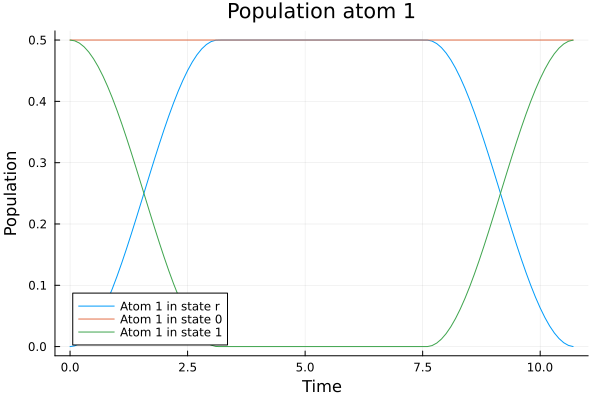

In [17]:
plot(tspan,popr_atom1, label="Atom 1 in state r", title="Population atom 1", xlabel="Time", ylabel="Population",legend=:bottomleft)
plot!(tspan,pop0_atom1, label="Atom 1 in state 0")
plot!(tspan,pop1_atom1,label="Atom 1 in state 1")

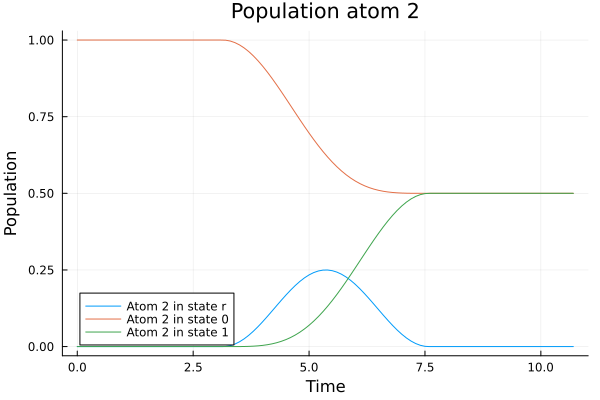

In [18]:
plot(tspan,popr_atom2, label="Atom 2 in state r", title="Population atom 2", xlabel="Time", ylabel="Population",legend=:bottomleft)
plot!(tspan,pop0_atom2, label="Atom 2 in state 0")
plot!(tspan,pop1_atom2,label="Atom 2 in state 1")

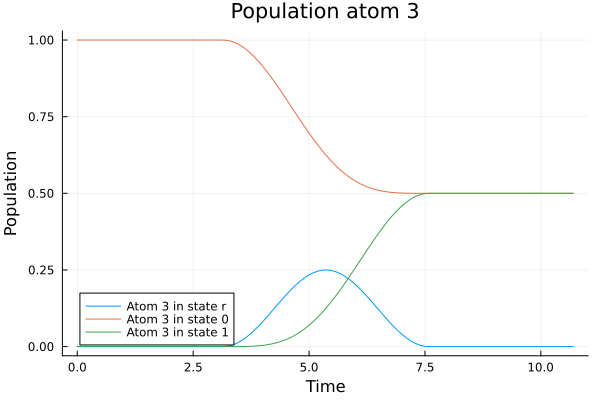

In [19]:
plot(tspan,popr_atom3, label="Atom 3 in state r", title="Population atom 3", xlabel="Time", ylabel="Population",legend=:bottomleft)
plot!(tspan,pop0_atom3, label="Atom 3 in state 0")
plot!(tspan,pop1_atom3,label="Atom 3 in state 1")

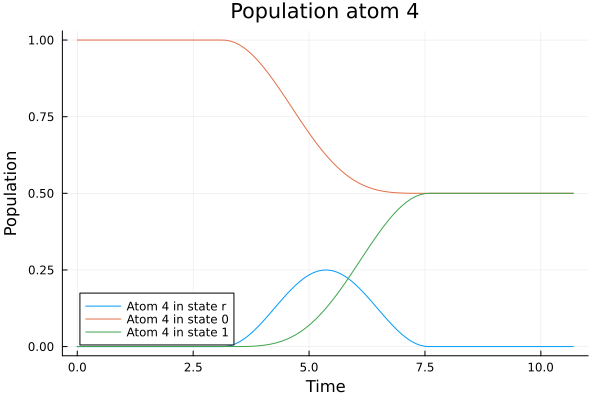

In [20]:
plot(tspan,popr_atom4, label="Atom 4 in state r", title="Population atom 4", xlabel="Time", ylabel="Population",legend=:bottomleft)
plot!(tspan,pop0_atom4, label="Atom 4 in state 0")
plot!(tspan,pop1_atom4,label="Atom 4 in state 1")

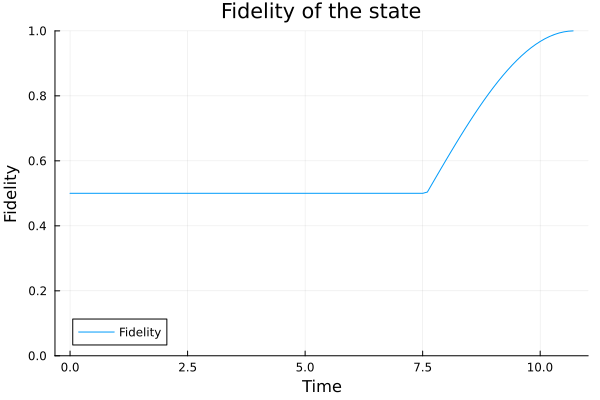

In [21]:
fidelities = []
ψ_target = α .* reduce(kron,[b,b,b,b]) + β .* reduce(kron,[a,a,a,a])
# ψ_one = a
# ψ_target = reduce(kron,[ψ_target1,ψ_one])
ρ_target = ψ_target * ψ_target'

for ρ in sol
    push!(fidelities,tr(sqrt(sqrt(ρ.data)*ρ_target*sqrt(ρ.data))))
end

plot(tspan,real(fidelities),ylim=[0,1],label="Fidelity", title="Fidelity of the state", xlabel="Time", ylabel="Fidelity",legend=:bottomleft)

## 5 atoms

In [20]:
const a = ComplexF64[1,0,0];        #Qubit state |0>
const b = ComplexF64[0,1,0];        #Qubit state |1>
const r = ComplexF64[0,0,1];       #Qubit state |r>

α = sqrt(0.5)
β = sqrt(1 - α^2)
ψ_1 = α .* b + β .* a; #Qubit state |ψ_1>
# ψ_1 = b
ψ_2 = a
ψ_3 = a
ψ_4 = a
ψ_5 = a


ψ_a_op = Ket(NLevelBasis(3),ψ_1) ⊗ Ket(NLevelBasis(3),ψ_2) ⊗ Ket(NLevelBasis(3), ψ_3) ⊗ Ket(NLevelBasis(3), ψ_4)⊗ Ket(NLevelBasis(3), ψ_5)
ρ0_op = ψ_a_op ⊗ dagger(ψ_a_op);

In [21]:
function Precomputed_ops()
    basis = NLevelBasis(3)
    σx_1r = transition(basis, 2, 3) + transition(basis, 3, 2) #|1> <-> |r>
    σx_0r = transition(basis, 1, 3) + transition(basis, 3, 1) #|0> <-> |r>
    n_r = transition(basis, 3, 3) #|r> <-> |r>
    I2 = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis,3,3) #|0> <-> |0> + |1> <-> |1>


    σx_1r_atom1 = σx_1r ⊗ I2 ⊗ I2 ⊗ I2 ⊗ I2

    σx_1r_atom2 = I2 ⊗ σx_1r ⊗ I2 ⊗ I2 ⊗ I2
    σx_0r_atom2 = I2 ⊗ σx_0r ⊗ I2 ⊗ I2 ⊗ I2
    n_r_atom2 = I2 ⊗ n_r ⊗ I2 ⊗ I2 ⊗ I2
    nn_r12 = n_r ⊗ n_r ⊗ I2 ⊗ I2 ⊗ I2

    σx_1r_atom3 = I2 ⊗ I2 ⊗ σx_1r ⊗ I2 ⊗ I2
    σx_0r_atom3 = I2 ⊗ I2 ⊗ σx_0r ⊗ I2 ⊗ I2
    n_r_atom3 = I2 ⊗ I2 ⊗ n_r ⊗ I2 ⊗ I2
    nn_r13 = n_r ⊗ I2 ⊗ n_r ⊗ I2 ⊗ I2

    σx_1r_atom4 = I2 ⊗ I2 ⊗ I2 ⊗ σx_1r ⊗ I2
    σx_0r_atom4 = I2 ⊗ I2 ⊗ I2 ⊗ σx_0r ⊗ I2
    n_r_atom4 =  I2 ⊗ I2 ⊗ I2 ⊗ n_r ⊗ I2
    nn_r14 = n_r ⊗ I2 ⊗ I2 ⊗ n_r ⊗ I2

    σx_1r_atom5 = I2 ⊗ I2 ⊗ I2 ⊗ I2 ⊗ σx_1r
    σx_0r_atom5 = I2 ⊗ I2 ⊗ I2 ⊗ I2 ⊗ σx_0r 
    n_r_atom5 =  I2 ⊗ I2 ⊗ I2 ⊗ I2 ⊗ n_r
    nn_r15 = n_r ⊗ I2 ⊗ I2 ⊗ I2 ⊗ n_r


    return (σx_1r_atom1, σx_1r_atom2, σx_0r_atom2, σx_1r_atom3, σx_0r_atom3, σx_1r_atom4, σx_0r_atom4, σx_1r_atom5, σx_0r_atom5,
     n_r_atom2, n_r_atom3, n_r_atom4, n_r_atom5, nn_r12, nn_r13, nn_r14, nn_r15)
end

const ops = Precomputed_ops();


function Ht(t)
    if t <= π
        Ω1 = 1.0
        Ω2 = 0.0
    elseif t < (π+sqrt(2)π)
        Ω1 = 0.0
        Ω2 = 1.0
    else 
        Ω1 = 1.0
        Ω2 = 0.0
    end

    σx_1r_atom1, σx_1r_atom2, σx_0r_atom2, σx_1r_atom3, σx_0r_atom3, σx_1r_atom4, σx_0r_atom4, σx_1r_atom5, σx_0r_atom5, n_r_atom2, n_r_atom3, n_r_atom4, n_r_atom5, nn_r12, nn_r13, nn_r14, nn_r15 = ops

    H = (Ω1/2 .* σx_1r_atom1 + Ω2/2 .* (σx_0r_atom2 + σx_1r_atom2) + Δ_0 .* n_r_atom2 + V_nn .* nn_r12 #+
        + Ω2/2 .* (σx_0r_atom3 + σx_1r_atom3) + Δ_0 .* n_r_atom3 + V_nn .* nn_r13
        + Ω2/2 .* (σx_0r_atom4 + σx_1r_atom4) + Δ_0 .* n_r_atom4 + V_nn .* nn_r14
        + Ω2/2 .* (σx_0r_atom5 + σx_1r_atom5) + Δ_0 .* n_r_atom5 + V_nn .* nn_r15)
    return H
end

function f(t,ρ)
    H = Ht(t)
    J = Operator[]
    return (H, J, dagger.(J))
end


f (generic function with 1 method)

In [22]:
const Δ_0 = -1000
const Ω1 = 1.0
const Ω2 = 1.0
const γ_Decay = 0.0
const γ_dephase = 0.0
const V_nn = 1000;

In [23]:
# tspan = [0.0:0.1:(3.5π);];
tspan = [0.0:0.1:(2π+sqrt(2)π);]
tout, sol = timeevolution.master_dynamic(tspan, ρ0_op, f; alg=ROCK4());

In [24]:
pop0_atom1 = []
pop1_atom1 = []
popr_atom1 = []

popr_atom2 = []
pop0_atom2 = []
pop1_atom2 = []

popr_atom3 = []
pop0_atom3 = []
pop1_atom3 = []

popr_atom4 = []
pop0_atom4 = []
pop1_atom4 = []

popr_atom5 = []
pop0_atom5 = []
pop1_atom5 = []

k = NLevelBasis(3)
n0 = transition(k, 1, 1)
n1 = transition(k, 2, 2)
nr = transition(k, 3, 3)
I2 = transition(k, 1, 1) + transition(k, 2, 2) + transition(k, 3, 3)

n0_atom1 = (n0 ⊗ I2 ⊗ I2 ⊗ I2 ⊗ I2)
n0_atom2 = (I2 ⊗ n0 ⊗ I2 ⊗ I2 ⊗ I2)
n0_atom3 = (I2 ⊗ I2 ⊗ n0 ⊗ I2 ⊗ I2)
n0_atom4 = (I2 ⊗ I2 ⊗ I2 ⊗ n0 ⊗ I2)
n0_atom5 = (I2 ⊗ I2 ⊗ I2 ⊗ I2 ⊗ n0)

n1_atom1 = (n1 ⊗ I2 ⊗ I2 ⊗ I2 ⊗ I2)
n1_atom2 = (I2 ⊗ n1 ⊗ I2 ⊗ I2 ⊗ I2)
n1_atom3 = (I2 ⊗ I2 ⊗ n1 ⊗ I2 ⊗ I2)
n1_atom4 = (I2 ⊗ I2 ⊗ I2 ⊗ n1 ⊗ I2)
n1_atom5 = (I2 ⊗ I2 ⊗ I2 ⊗ I2 ⊗ n1)

nr_atom1 = (nr ⊗ I2 ⊗ I2 ⊗ I2 ⊗ I2)
nr_atom2 = (I2 ⊗ nr ⊗ I2 ⊗ I2 ⊗ I2)
nr_atom3 = (I2 ⊗ I2 ⊗ nr ⊗ I2 ⊗ I2)
nr_atom4 = (I2 ⊗ I2 ⊗ I2 ⊗ nr ⊗ I2)
nr_atom5 = (I2 ⊗ I2 ⊗ I2 ⊗ I2 ⊗ nr)


for ρ in sol
    push!(popr_atom1, real(tr(nr_atom1*ρ)))
    push!(pop0_atom1, real(tr(n0_atom1*ρ)))
    push!(pop1_atom1, real(tr(n1_atom1*ρ)))
    push!(popr_atom2, real(tr(nr_atom2*ρ)))
    push!(pop0_atom2, real(tr(n0_atom2*ρ)))
    push!(pop1_atom2, real(tr(n1_atom2*ρ)))
    
    push!(pop0_atom3, real(tr(n0_atom3*ρ)))
    push!(pop1_atom3, real(tr(n1_atom3*ρ)))
    push!(popr_atom3, real(tr(nr_atom3*ρ)))

    push!(pop0_atom4, real(tr(n0_atom4*ρ)))
    push!(pop1_atom4, real(tr(n1_atom4*ρ)))
    push!(popr_atom4, real(tr(nr_atom4*ρ)))

    push!(pop0_atom5, real(tr(n0_atom5*ρ)))
    push!(pop1_atom5, real(tr(n1_atom5*ρ)))
    push!(popr_atom5, real(tr(nr_atom5*ρ)))
end

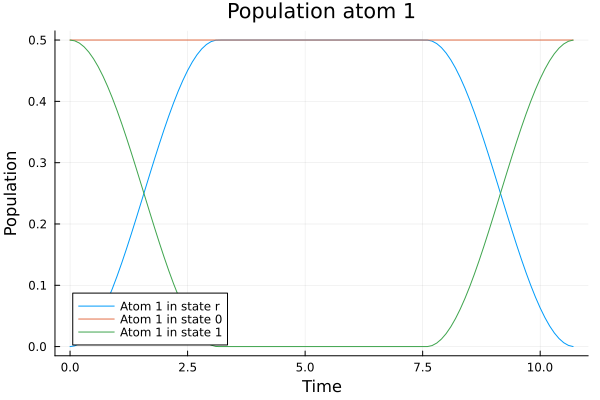

In [25]:
plot(tspan,popr_atom1, label="Atom 1 in state r", title="Population atom 1", xlabel="Time", ylabel="Population",legend=:bottomleft)
plot!(tspan,pop0_atom1, label="Atom 1 in state 0")
plot!(tspan,pop1_atom1,label="Atom 1 in state 1")

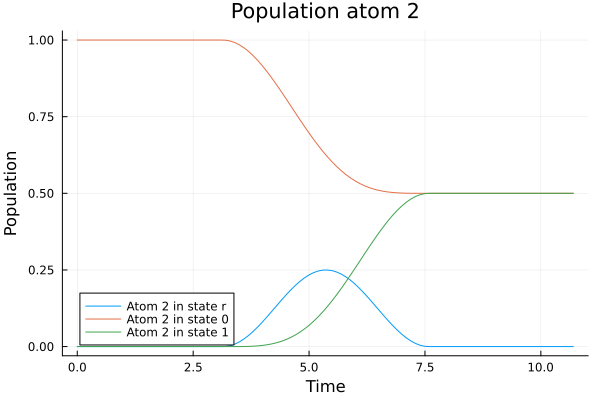

In [26]:
plot(tspan,popr_atom2, label="Atom 2 in state r", title="Population atom 2", xlabel="Time", ylabel="Population",legend=:bottomleft)
plot!(tspan,pop0_atom2, label="Atom 2 in state 0")
plot!(tspan,pop1_atom2,label="Atom 2 in state 1")

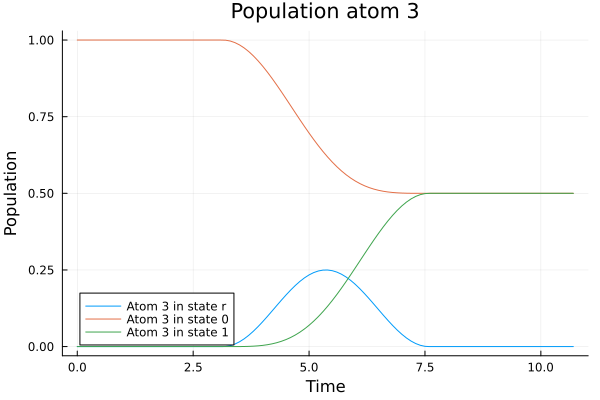

In [27]:
plot(tspan,popr_atom3, label="Atom 3 in state r", title="Population atom 3", xlabel="Time", ylabel="Population",legend=:bottomleft)
plot!(tspan,pop0_atom3, label="Atom 3 in state 0")
plot!(tspan,pop1_atom3,label="Atom 3 in state 1")

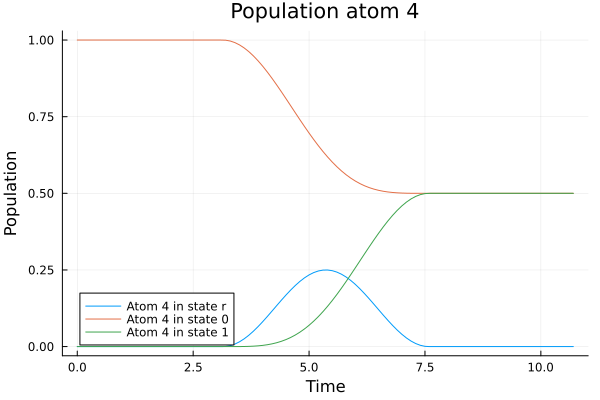

In [28]:
plot(tspan,popr_atom4, label="Atom 4 in state r", title="Population atom 4", xlabel="Time", ylabel="Population",legend=:bottomleft)
plot!(tspan,pop0_atom4, label="Atom 4 in state 0")
plot!(tspan,pop1_atom4,label="Atom 4 in state 1")

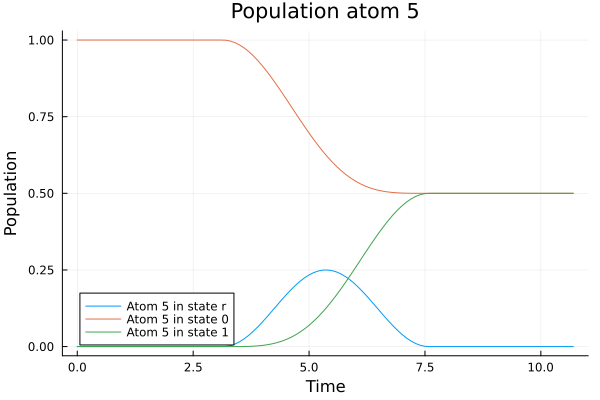

In [29]:
plot(tspan,popr_atom5, label="Atom 5 in state r", title="Population atom 5", xlabel="Time", ylabel="Population",legend=:bottomleft)
plot!(tspan,pop0_atom5, label="Atom 5 in state 0")
plot!(tspan,pop1_atom5,label="Atom 5 in state 1")

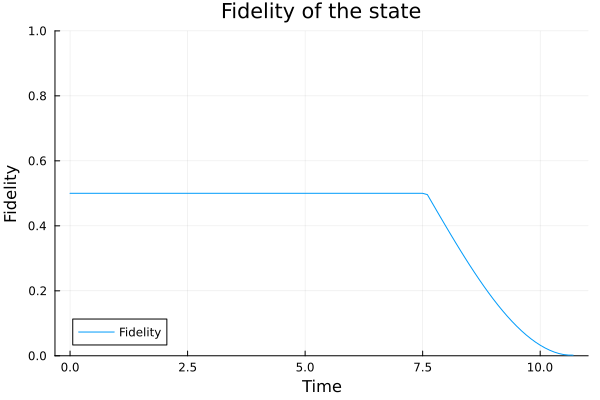

In [30]:
fidelities = []
ψ_target = α .* reduce(kron,[b,b,b,b,b]) + β .* reduce(kron,[a,a,a,a,a])
# ψ_one = a
# ψ_target = reduce(kron,[ψ_target1,ψ_one])
ρ_target = ψ_target * ψ_target'

for ρ in sol
    push!(fidelities,tr(sqrt(sqrt(ρ.data)*ρ_target*sqrt(ρ.data))))
end

plot(tspan,real(fidelities),ylim=[0,1],label="Fidelity", title="Fidelity of the state", xlabel="Time", ylabel="Fidelity",legend=:bottomleft)